# Gan 학습시켜보기~
---

#### 라이브러리

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

#### GPU 확인

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


#### MINIST 데이터 가지고오기

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

#### Generator & Discriminator
- 랜덤 노이즈를 주고 28x28 이미지를 만든다.
[랜덤 숫자 100개]
       ↓
   Generator
       ↓
784개 숫자
       ↓
28 × 28 이미지


In [17]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [18]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

#### 모델 생성

In [19]:
G = Generator().to(device)
D = Discriminator().to(device)

print(G)
print(D)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


#### Loss

In [20]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    G.parameters(),
    lr=0.0002
)

optimizer_D = optim.Adam(
    D.parameters(),
    lr=0.0002
)

#### 학습

Epoch [1/20] D Loss: 0.0375 G Loss: 5.9325


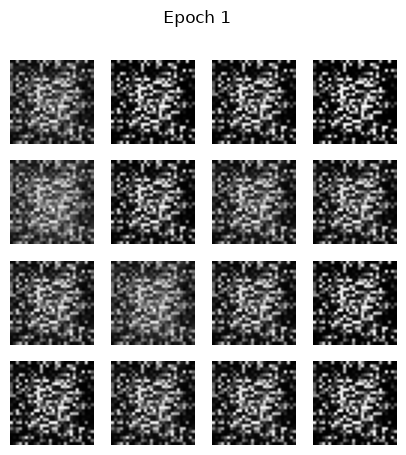

Epoch [2/20] D Loss: 0.6776 G Loss: 4.9900


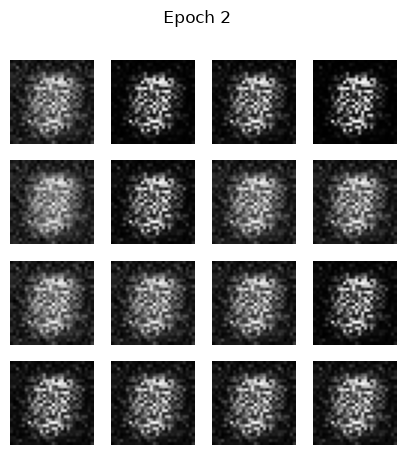

Epoch [3/20] D Loss: 0.4729 G Loss: 3.1331


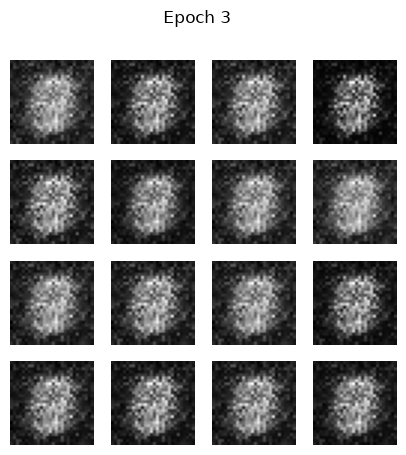

Epoch [4/20] D Loss: 0.3833 G Loss: 3.2535


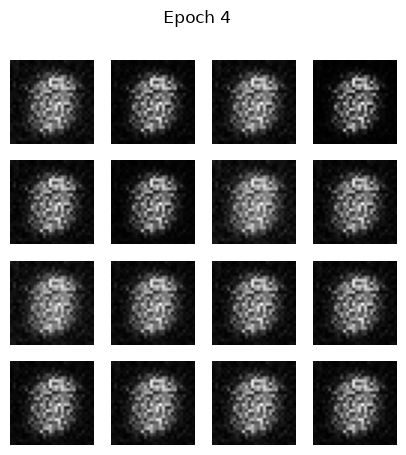

Epoch [5/20] D Loss: 1.3850 G Loss: 1.3424


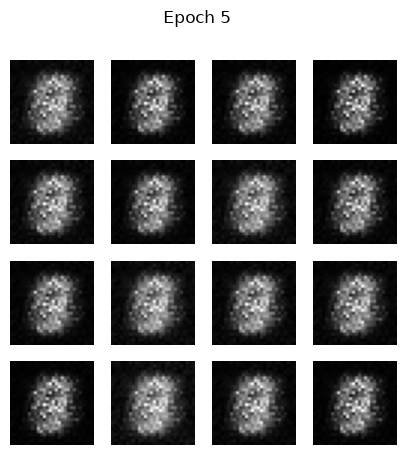

Epoch [6/20] D Loss: 0.1655 G Loss: 3.8301


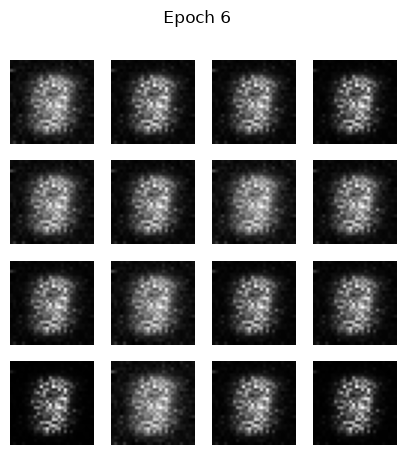

Epoch [7/20] D Loss: 0.4759 G Loss: 2.9431


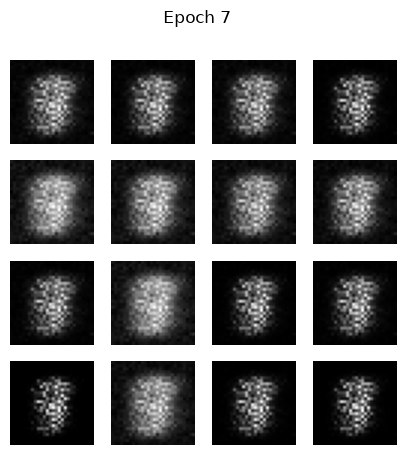

Epoch [8/20] D Loss: 0.1000 G Loss: 4.7214


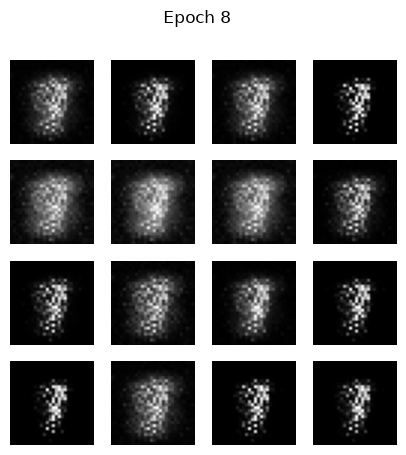

Epoch [9/20] D Loss: 0.0895 G Loss: 4.3211


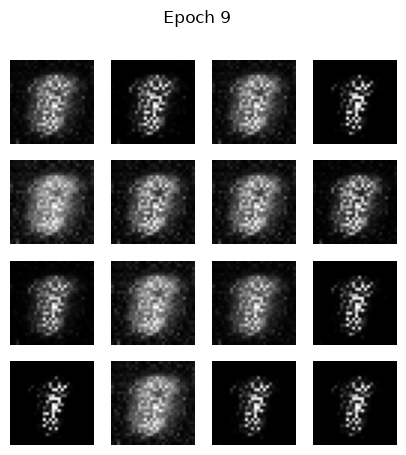

Epoch [10/20] D Loss: 0.1764 G Loss: 4.8214


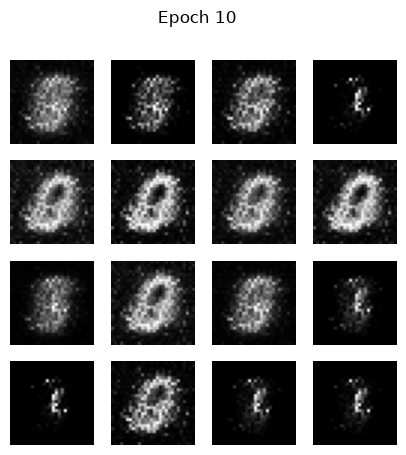

Epoch [11/20] D Loss: 0.0817 G Loss: 5.5749


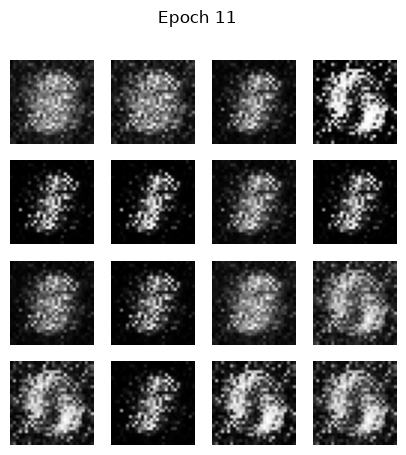

Epoch [12/20] D Loss: 0.2993 G Loss: 5.1287


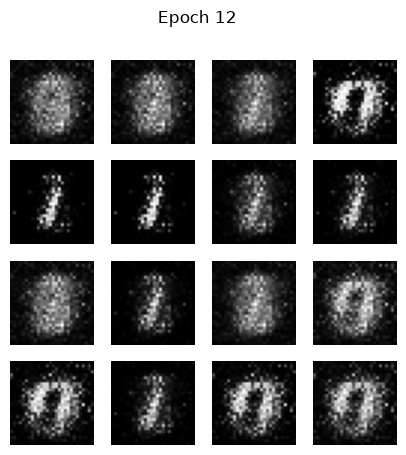

Epoch [13/20] D Loss: 0.1254 G Loss: 4.3646


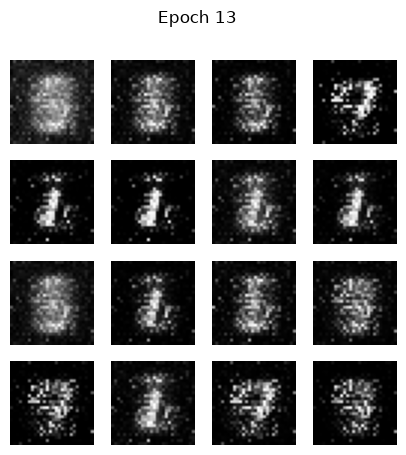

Epoch [14/20] D Loss: 0.2659 G Loss: 5.1547


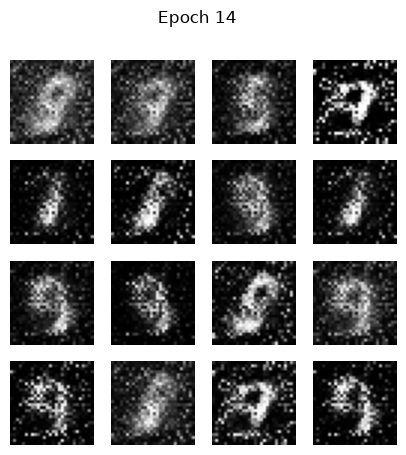

Epoch [15/20] D Loss: 0.1774 G Loss: 4.7558


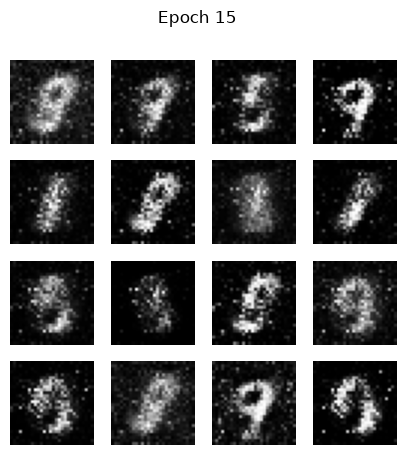

Epoch [16/20] D Loss: 0.3451 G Loss: 5.6171


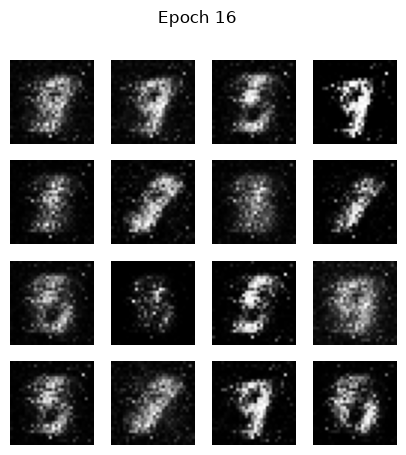

Epoch [17/20] D Loss: 0.1132 G Loss: 6.3056


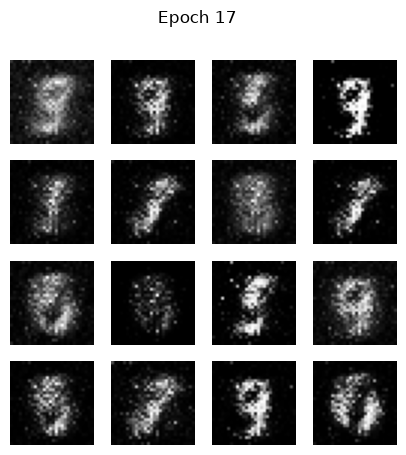

Epoch [18/20] D Loss: 0.3866 G Loss: 6.1522


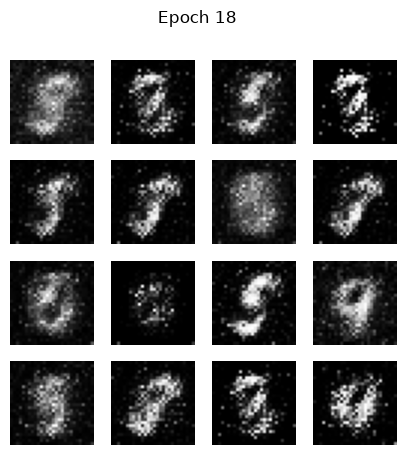

Epoch [19/20] D Loss: 0.2733 G Loss: 4.3593


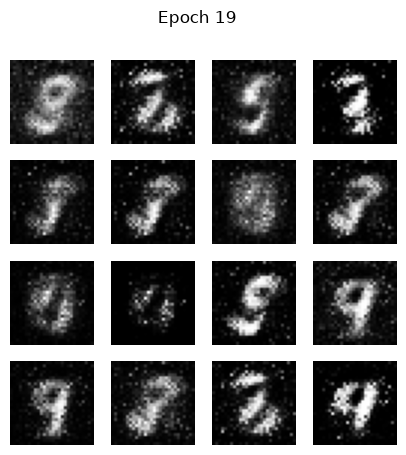

Epoch [20/20] D Loss: 0.1165 G Loss: 5.2236


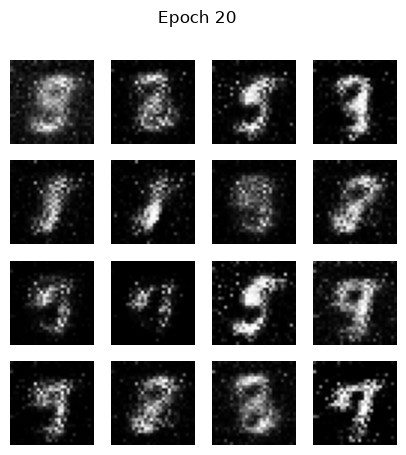

In [21]:
epochs = 20
latent_dim = 100

fixed_noise = torch.randn(16, latent_dim).to(device)

for epoch in range(epochs):

    for real_images, _ in dataloader:

        batch_size = real_images.size(0)

        real_images = real_images.view(batch_size, -1).to(device)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # =========================
        # 1. Discriminator 학습
        # =========================

        optimizer_D.zero_grad()

        real_output = D(real_images)
        real_loss = criterion(real_output, real_labels)

        noise = torch.randn(batch_size, latent_dim).to(device)

        fake_images = G(noise)

        fake_output = D(fake_images.detach())
        fake_loss = criterion(fake_output, fake_labels)

        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_D.step()

        # =========================
        # 2. Generator 학습
        # =========================

        optimizer_G.zero_grad()

        fake_output = D(fake_images)

        g_loss = criterion(fake_output, real_labels)

        g_loss.backward()
        optimizer_G.step()

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

    # =========================
    # 매 epoch 생성 이미지 확인
    # =========================

    G.eval()

    with torch.no_grad():
        sample_images = G(fixed_noise)
        sample_images = sample_images.view(-1, 1, 28, 28).cpu()

    G.train()

    fig, axes = plt.subplots(4, 4, figsize=(5, 5))

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(sample_images[i].squeeze(), cmap="gray")
        ax.axis("off")

    plt.suptitle(f"Epoch {epoch + 1}")
    plt.show()